# Instructor Performance and Course Quality Evaluation on EduPro
## Comprehensive Data Analysis

**Project Objective:** Evaluate instructor effectiveness and course quality to drive data-driven improvements in online education.

**Key Focus Areas:**
- Instructor performance distribution
- Experience vs rating correlation
- Course quality by category and level
- Expertise-based insights
- Enrollment patterns

## 1. Import Libraries and Load Data

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Load datasets
print("Loading datasets...")
teachers_df = pd.read_csv('teachers.csv')
courses_df = pd.read_csv('courses.csv')
transactions_df = pd.read_csv('transactions.csv')

Loading datasets...


## 2. Data Exploration and Understanding

In [8]:
# Teachers dataset overview
print("="*80)
print("TEACHERS DATASET")
print("="*80)
print("\nFirst 5 rows:")
display(teachers_df.head())
print("\nDataset Info:")
print(teachers_df.info())
print("\nStatistical Summary:")
display(teachers_df.describe())
print("\nMissing Values:")
print(teachers_df.isnull().sum())

TEACHERS DATASET

First 5 rows:


,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     object 
 1   TeacherName        60 non-null     object 
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     object 
 4   Expertise          60 non-null     object 
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 3.4+ KB
None

Statistical Summary:


,Age,YearsOfExperience,TeacherRating
count,60.000000,60.000000,60.000000
mean,38.450000,6.283333,3.125000
std,7.703015,4.715972,0.949797
min,27.000000,1.000000,1.050000
25%,32.000000,3.000000,2.487500
50%,36.500000,6.000000,3.275000
75%,46.250000,8.000000,3.827500
max,50.000000,24.000000,4.970000



Missing Values:
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64


In [9]:
# Courses dataset overview
print("="*80)
print("COURSES DATASET")
print("="*80)
print("\nFirst 5 rows:")
display(courses_df.head())
print("\nDataset Info:")
print(courses_df.info())
print("\nStatistical Summary:")
display(courses_df.describe())
print("\nMissing Values:")
print(courses_df.isnull().sum())

COURSES DATASET

First 5 rows:


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     object 
 1   CourseName      60 non-null     object 
 2   CourseCategory  60 non-null     object 
 3   CourseType      60 non-null     object 
 4   CourseLevel     60 non-null     object 
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), object(5)
memory usage: 3.9+ KB
None

Statistical Summary:


,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000



Missing Values:
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64


In [10]:
# Transactions dataset overview
print("="*80)
print("TRANSACTIONS DATASET")
print("="*80)
print("\nFirst 5 rows:")
display(transactions_df.head())
print("\nDataset Info:")
print(transactions_df.info())
print("\nStatistical Summary:")
display(transactions_df.describe())
print("\nMissing Values:")
print(transactions_df.isnull().sum())

TRANSACTIONS DATASET

First 5 rows:


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    10000 non-null  object 
 1   UserID           10000 non-null  object 
 2   CourseID         10000 non-null  object 
 3   TransactionDate  10000 non-null  object 
 4   Amount           10000 non-null  float64
 5   PaymentMethod    10000 non-null  object 
 6   TeacherID        10000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.0+ KB
None

Statistical Summary:


,Amount
count,10000.000000
mean,91.132347
std,152.063524
min,0.000000
25%,0.000000
50%,0.000000
75%,119.040000
max,490.900000



Missing Values:
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64


## 3. Data Integration and Preparation

In [11]:
# Merge transactions with courses
merged_df = transactions_df.merge(courses_df, on='CourseID', how='left')
print(f"After merging Transactions + Courses: {merged_df.shape}")

# Merge with teachers
merged_df = merged_df.merge(teachers_df, on='TeacherID', how='left')
print(f"After merging with Teachers: {merged_df.shape}")

print("\nMerged Dataset - First 5 rows:")
display(merged_df.head())

print("\nMissing values after merge:")
print(merged_df.isnull().sum())

After merging Transactions + Courses: (10000, 14)
After merging with Teachers: (10000, 20)

Merged Dataset - First 5 rows:


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TT00001,U00003,CR00016,25/10/2025,0.0,PayPal,TC00040,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72,Kimberly Miller,49,Male,Cybersecurity,24,4.58
1,TT00002,U00003,CR00037,13/1/2025,0.0,PayPal,TC00040,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,TT00003,U00003,CR00019,28/3/2025,0.0,Bank Transfer,TC00040,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98,Kimberly Miller,49,Male,Cybersecurity,24,4.58
3,TT00004,U00004,CR00048,2/6/2025,0.0,Bank Transfer,TC00040,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64,Kimberly Miller,49,Male,Cybersecurity,24,4.58
4,TT00005,U00004,CR00060,10/8/2025,0.0,PayPal,TC00042,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14,Yolanda Levine,49,Female,Machine Learning,21,4.97



Missing values after merge:
TransactionID        0
UserID               0
CourseID             0
TransactionDate      0
Amount               0
PaymentMethod        0
TeacherID            0
CourseName           0
CourseCategory       0
CourseType           0
CourseLevel          0
CoursePrice          0
CourseDuration       0
CourseRating         0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64


In [12]:
# Data quality checks
print("="*80)
print("DATA QUALITY VALIDATION")
print("="*80)

# Check for duplicate transactions
duplicates = merged_df.duplicated(subset=['TransactionID']).sum()
print(f"\nDuplicate Transactions: {duplicates}")

# Check unique counts
print(f"\nUnique Teachers: {merged_df['TeacherID'].nunique()}")
print(f"Unique Courses: {merged_df['CourseID'].nunique()}")
print(f"Total Enrollments: {merged_df.shape[0]}")

# Rating ranges validation
print(f"\nTeacher Rating Range: {merged_df['TeacherRating'].min():.2f} - {merged_df['TeacherRating'].max():.2f}")
print(f"Course Rating Range: {merged_df['CourseRating'].min():.2f} - {merged_df['CourseRating'].max():.2f}")
print(f"Experience Range: {merged_df['YearsOfExperience'].min()} - {merged_df['YearsOfExperience'].max()} years")

DATA QUALITY VALIDATION

Duplicate Transactions: 0

Unique Teachers: 60
Unique Courses: 60
Total Enrollments: 10000

Teacher Rating Range: 1.05 - 4.97
Course Rating Range: 1.13 - 4.94
Experience Range: 1 - 24 years


## 4. Instructor Profile Analysis

In [13]:
# Aggregate instructor-level metrics
instructor_profile = teachers_df.copy()

# Add enrollment count per instructor
enrollment_counts = merged_df.groupby('TeacherID').size().reset_index(name='TotalEnrollments')
instructor_profile = instructor_profile.merge(enrollment_counts, on='TeacherID', how='left')
instructor_profile['TotalEnrollments'].fillna(0, inplace=True)

# Add average course rating per instructor
avg_course_rating = merged_df.groupby('TeacherID')['CourseRating'].mean().reset_index(name='AvgCourseRating')
instructor_profile = instructor_profile.merge(avg_course_rating, on='TeacherID', how='left')

print("Instructor Profile Summary:")
display(instructor_profile.head(10))
print("\nStatistical Overview:")
display(instructor_profile.describe())

Instructor Profile Summary:


,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating,TotalEnrollments,AvgCourseRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24,36,2.853611
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14,68,3.708824
2,TC00003,Amber Torres,32,Male,Design,4,1.56,59,3.107627
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39,47,2.549362
4,TC00005,David Williams,34,Male,Finance,2,3.11,47,2.789787
5,TC00006,Rebecca Webb,49,Male,Cybersecurity,14,3.36,48,3.218333
6,TC00007,Angela Beard,28,Female,Machine Learning,6,4.36,49,2.510816
7,TC00008,Steven Walker,41,Male,Data Science,15,3.54,133,3.267218
8,TC00009,Alexander Tucker,49,Female,Project Management,2,2.22,58,3.174310
9,TC00010,Frances Sanchez,29,Male,Data Science,1,2.18,81,3.335062



Statistical Overview:


,Age,YearsOfExperience,TeacherRating,TotalEnrollments,AvgCourseRating
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,38.450000,6.283333,3.125000,166.666667,3.159811
std,7.703015,4.715972,0.949797,539.784975,0.290931
min,27.000000,1.000000,1.050000,23.000000,2.510816
25%,32.000000,3.000000,2.487500,46.000000,2.959628
50%,36.500000,6.000000,3.275000,56.500000,3.176814
75%,46.250000,8.000000,3.827500,93.500000,3.300436
max,50.000000,24.000000,4.970000,3061.000000,3.868000


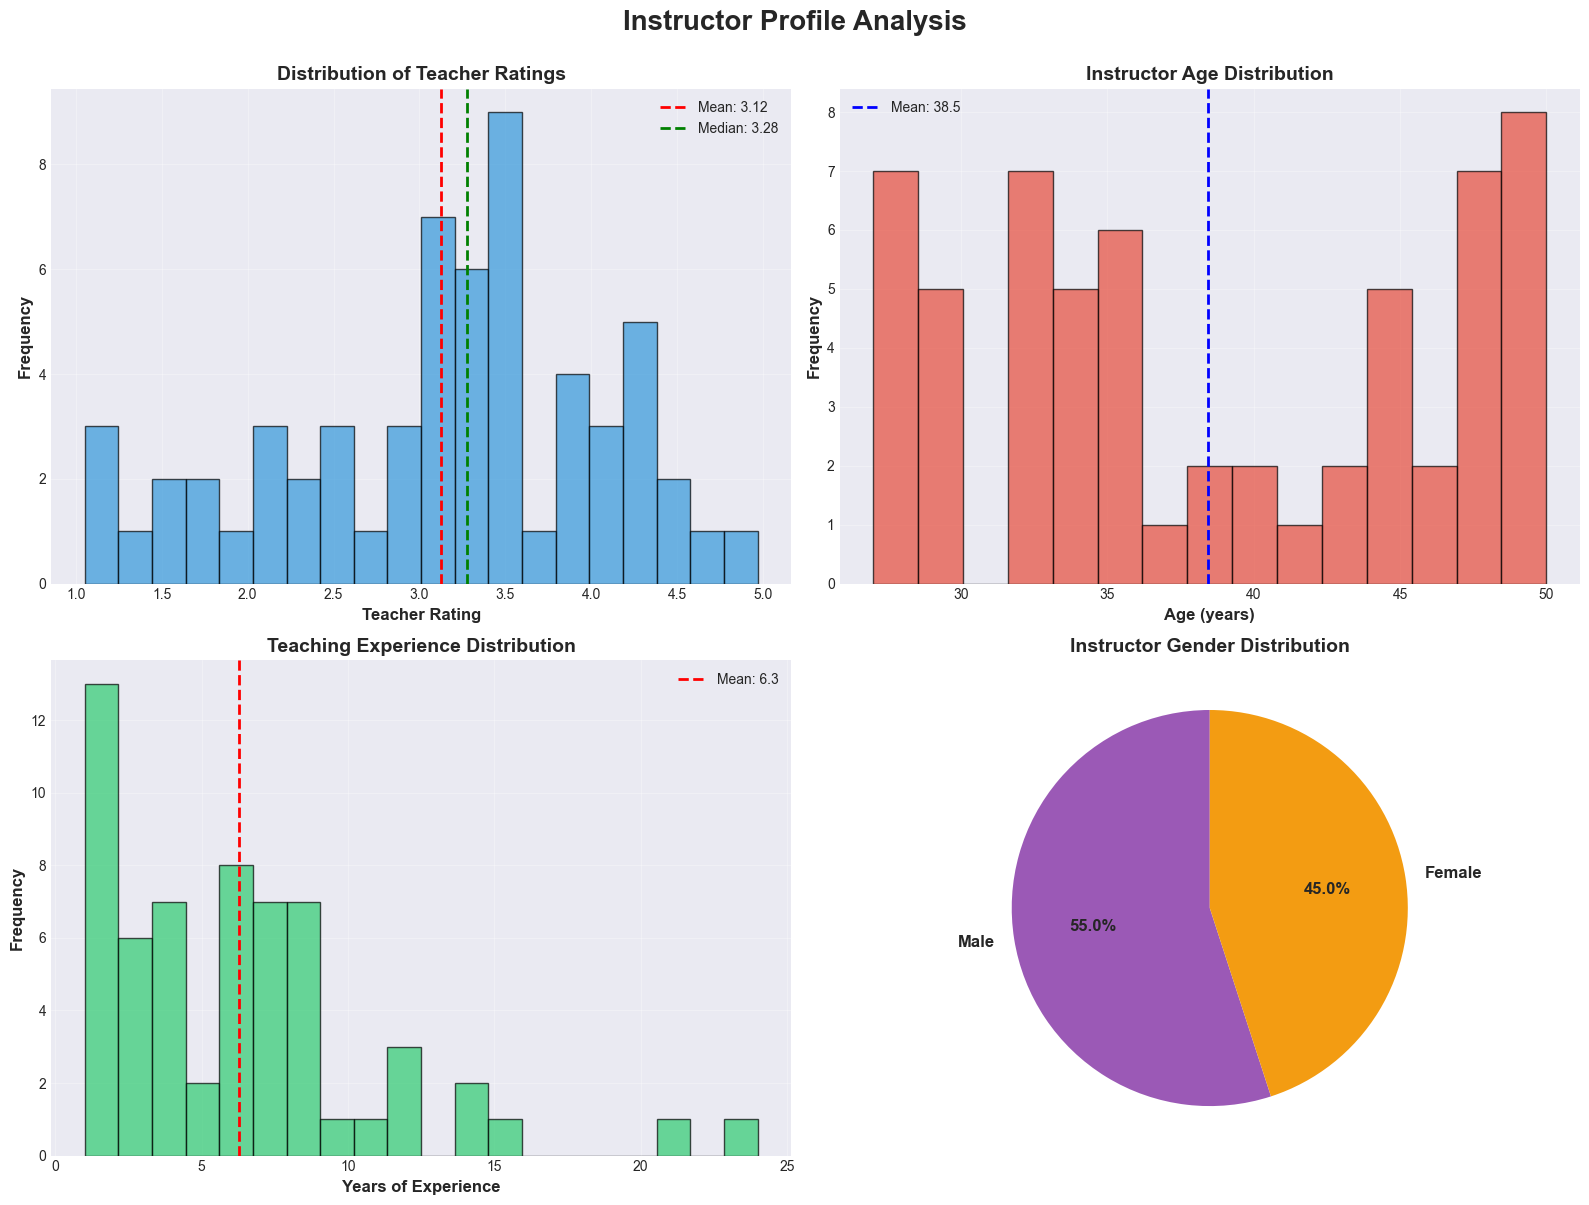


📊 Visualization saved: instructor_profile_analysis.png


In [14]:
# Visualization 1: Distribution of Instructor Ratings
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Instructor Profile Analysis', fontsize=20, fontweight='bold', y=1.00)

# Subplot 1: Teacher Rating Distribution
axes[0, 0].hist(instructor_profile['TeacherRating'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(instructor_profile['TeacherRating'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {instructor_profile['TeacherRating'].mean():.2f}")
axes[0, 0].axvline(instructor_profile['TeacherRating'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {instructor_profile['TeacherRating'].median():.2f}")
axes[0, 0].set_xlabel('Teacher Rating', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Distribution of Teacher Ratings', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Subplot 2: Age Distribution
axes[0, 1].hist(instructor_profile['Age'], bins=15, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(instructor_profile['Age'].mean(), color='blue', linestyle='--', linewidth=2, label=f"Mean: {instructor_profile['Age'].mean():.1f}")
axes[0, 1].set_xlabel('Age (years)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Instructor Age Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Subplot 3: Years of Experience Distribution
axes[1, 0].hist(instructor_profile['YearsOfExperience'], bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(instructor_profile['YearsOfExperience'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {instructor_profile['YearsOfExperience'].mean():.1f}")
axes[1, 0].set_xlabel('Years of Experience', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Teaching Experience Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Subplot 4: Gender Distribution
gender_counts = instructor_profile['Gender'].value_counts()
colors_gender = ['#9b59b6', '#f39c12']
axes[1, 1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=colors_gender, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1, 1].set_title('Instructor Gender Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('instructor_profile_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved: instructor_profile_analysis.png")

In [15]:
# Top and Bottom Performers
print("="*80)
print("TOP 10 INSTRUCTORS BY RATING")
print("="*80)
top_instructors = instructor_profile.nlargest(10, 'TeacherRating')[['TeacherName', 'TeacherRating', 'YearsOfExperience', 'Expertise', 'TotalEnrollments']]
display(top_instructors)

print("\n" + "="*80)
print("BOTTOM 10 INSTRUCTORS BY RATING")
print("="*80)
bottom_instructors = instructor_profile.nsmallest(10, 'TeacherRating')[['TeacherName', 'TeacherRating', 'YearsOfExperience', 'Expertise', 'TotalEnrollments']]
display(bottom_instructors)

TOP 10 INSTRUCTORS BY RATING


,TeacherName,TeacherRating,YearsOfExperience,Expertise,TotalEnrollments
41,Yolanda Levine,4.97,21,Machine Learning,3061
39,Kimberly Miller,4.58,24,Cybersecurity,3025
3,Kristi Scott,4.39,9,Machine Learning,47
36,Debra Escobar,4.39,8,Finance,117
6,Angela Beard,4.36,6,Machine Learning,49
52,Aaron Kirby,4.29,9,Marketing,120
17,Kari Pierce,4.28,11,Project Management,93
53,Shelby Patrick,4.28,7,Artificial Intelligence,46
23,Michael Kim,4.22,6,Digital Marketing,57
1,Jill Day,4.14,9,Digital Marketing,68



BOTTOM 10 INSTRUCTORS BY RATING


,TeacherName,TeacherRating,YearsOfExperience,Expertise,TotalEnrollments
42,John Williams,1.05,1,Project Management,68
27,Timothy Bailey,1.06,3,Business,161
44,Emily Gutierrez,1.07,5,Web Development,56
35,Brenda Mclean,1.39,4,Digital Marketing,46
26,Laurie Michael,1.55,3,Artificial Intelligence,133
2,Amber Torres,1.56,4,Design,59
50,John Obrien,1.77,2,Design,63
46,Brad Griffin,1.79,4,Design,65
30,Brenda Mercer,1.86,1,Cybersecurity,164
24,Justin Pham,2.17,4,Web Development,48


## 5. Experience vs Performance Analysis

In [16]:
# Correlation Analysis
print("="*80)
print("CORRELATION ANALYSIS: Experience vs Ratings")
print("="*80)

# Pearson correlation: Experience vs Teacher Rating
corr_exp_teacher, p_exp_teacher = pearsonr(instructor_profile['YearsOfExperience'], instructor_profile['TeacherRating'])
print(f"\nYears of Experience vs Teacher Rating")
print(f"  Pearson Correlation: {corr_exp_teacher:.4f}")
print(f"  P-value: {p_exp_teacher:.4e}")
print(f"  Significance: {'Yes' if p_exp_teacher < 0.05 else 'No'} (α=0.05)")

# Experience vs Average Course Rating
valid_instructors = instructor_profile.dropna(subset=['AvgCourseRating'])
if len(valid_instructors) > 0:
    corr_exp_course, p_exp_course = pearsonr(valid_instructors['YearsOfExperience'], valid_instructors['AvgCourseRating'])
    print(f"\nYears of Experience vs Average Course Rating")
    print(f"  Pearson Correlation: {corr_exp_course:.4f}")
    print(f"  P-value: {p_exp_course:.4e}")
    print(f"  Significance: {'Yes' if p_exp_course < 0.05 else 'No'} (α=0.05)")

# Teacher Rating vs Course Rating
corr_teacher_course, p_teacher_course = pearsonr(valid_instructors['TeacherRating'], valid_instructors['AvgCourseRating'])
print(f"\nTeacher Rating vs Average Course Rating")
print(f"  Pearson Correlation: {corr_teacher_course:.4f}")
print(f"  P-value: {p_teacher_course:.4e}")
print(f"  Significance: {'Yes' if p_teacher_course < 0.05 else 'No'} (α=0.05)")

CORRELATION ANALYSIS: Experience vs Ratings

Years of Experience vs Teacher Rating
  Pearson Correlation: 0.5980
  P-value: 4.5176e-07
  Significance: Yes (α=0.05)

Years of Experience vs Average Course Rating
  Pearson Correlation: -0.0569
  P-value: 6.6593e-01
  Significance: No (α=0.05)

Teacher Rating vs Average Course Rating
  Pearson Correlation: 0.0005
  P-value: 9.9710e-01
  Significance: No (α=0.05)


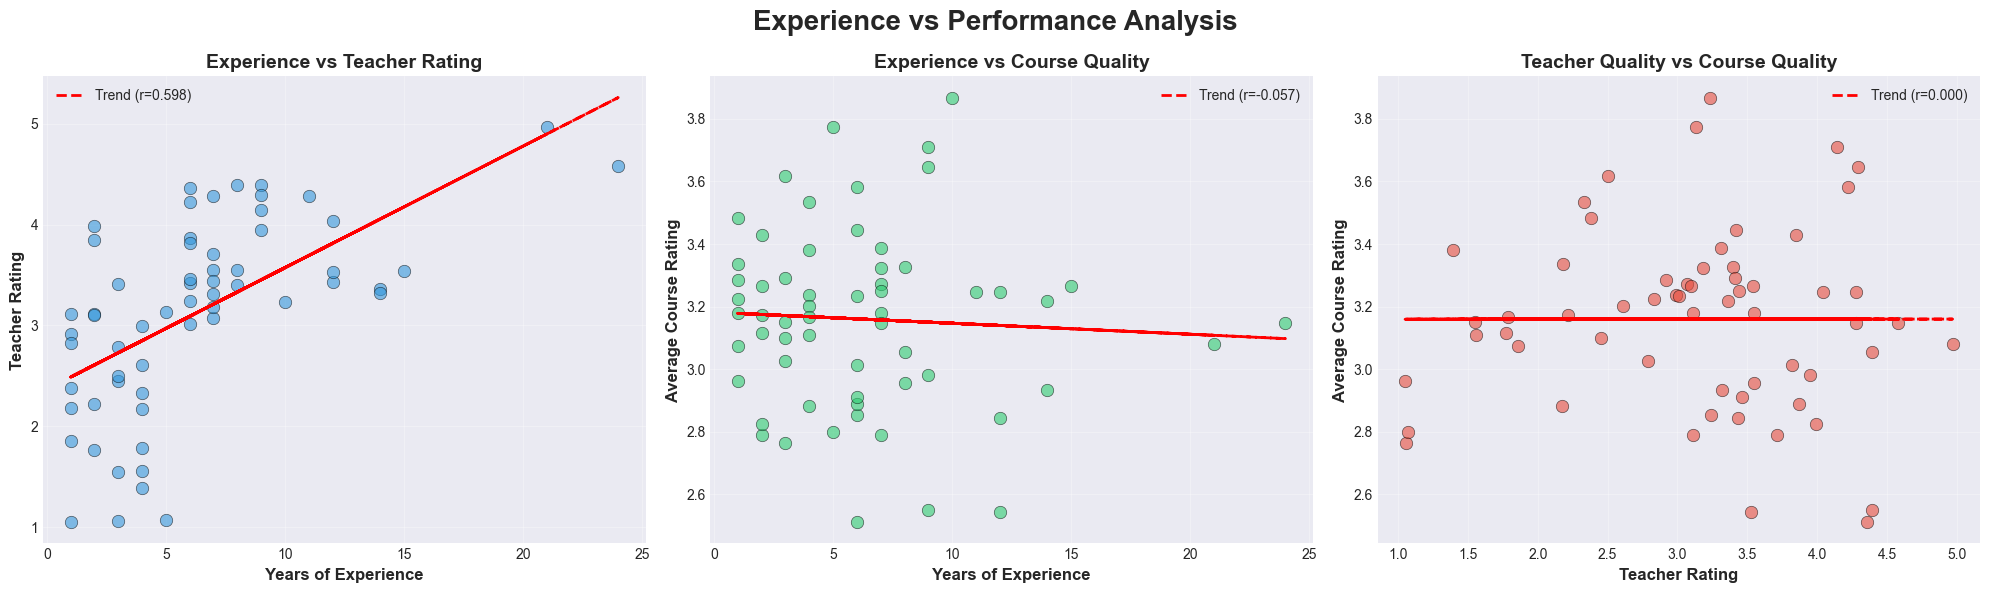


📊 Visualization saved: experience_performance_analysis.png


In [17]:
# Visualization 2: Experience vs Performance Scatter Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Experience vs Performance Analysis', fontsize=20, fontweight='bold')

# Subplot 1: Experience vs Teacher Rating
axes[0].scatter(instructor_profile['YearsOfExperience'], instructor_profile['TeacherRating'], 
                alpha=0.6, s=80, c='#3498db', edgecolors='black', linewidth=0.5)
z = np.polyfit(instructor_profile['YearsOfExperience'], instructor_profile['TeacherRating'], 1)
p = np.poly1d(z)
axes[0].plot(instructor_profile['YearsOfExperience'], p(instructor_profile['YearsOfExperience']), 
             "r--", linewidth=2, label=f'Trend (r={corr_exp_teacher:.3f})')
axes[0].set_xlabel('Years of Experience', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Teacher Rating', fontsize=12, fontweight='bold')
axes[0].set_title('Experience vs Teacher Rating', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Experience vs Average Course Rating
if len(valid_instructors) > 0:
    axes[1].scatter(valid_instructors['YearsOfExperience'], valid_instructors['AvgCourseRating'], 
                    alpha=0.6, s=80, c='#2ecc71', edgecolors='black', linewidth=0.5)
    z2 = np.polyfit(valid_instructors['YearsOfExperience'], valid_instructors['AvgCourseRating'], 1)
    p2 = np.poly1d(z2)
    axes[1].plot(valid_instructors['YearsOfExperience'], p2(valid_instructors['YearsOfExperience']), 
                 "r--", linewidth=2, label=f'Trend (r={corr_exp_course:.3f})')
axes[1].set_xlabel('Years of Experience', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Course Rating', fontsize=12, fontweight='bold')
axes[1].set_title('Experience vs Course Quality', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Subplot 3: Teacher Rating vs Course Rating
axes[2].scatter(valid_instructors['TeacherRating'], valid_instructors['AvgCourseRating'], 
                alpha=0.6, s=80, c='#e74c3c', edgecolors='black', linewidth=0.5)
z3 = np.polyfit(valid_instructors['TeacherRating'], valid_instructors['AvgCourseRating'], 1)
p3 = np.poly1d(z3)
axes[2].plot(valid_instructors['TeacherRating'], p3(valid_instructors['TeacherRating']), 
             "r--", linewidth=2, label=f'Trend (r={corr_teacher_course:.3f})')
axes[2].set_xlabel('Teacher Rating', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average Course Rating', fontsize=12, fontweight='bold')
axes[2].set_title('Teacher Quality vs Course Quality', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experience_performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved: experience_performance_analysis.png")

## 6. Course Quality Evaluation

In [18]:
# Course rating analysis by category and level
print("="*80)
print("COURSE QUALITY BY CATEGORY")
print("="*80)

category_stats = merged_df.groupby('CourseCategory').agg({
    'CourseRating': ['mean', 'median', 'std', 'count'],
    'TransactionID': 'count'
}).round(3)
category_stats.columns = ['Avg_Rating', 'Median_Rating', 'Std_Rating', 'Num_Courses', 'Total_Enrollments']
category_stats = category_stats.sort_values('Avg_Rating', ascending=False)
display(category_stats)

print("\n" + "="*80)
print("COURSE QUALITY BY LEVEL")
print("="*80)

level_stats = merged_df.groupby('CourseLevel').agg({
    'CourseRating': ['mean', 'median', 'std', 'count'],
    'TransactionID': 'count'
}).round(3)
level_stats.columns = ['Avg_Rating', 'Median_Rating', 'Std_Rating', 'Num_Courses', 'Total_Enrollments']
level_stats = level_stats.sort_values('Avg_Rating', ascending=False)
display(level_stats)

COURSE QUALITY BY CATEGORY


,Avg_Rating,Median_Rating,Std_Rating,Num_Courses,Total_Enrollments
CourseCategory,,,,,
Marketing,3.686,4.11,1.075,806,806
Digital Marketing,3.683,3.89,0.935,808,808
Data Science,3.335,3.60,0.441,916,916
Design,3.179,2.72,1.149,827,827
Project Management,3.123,3.45,1.539,829,829
Artificial Intelligence,3.122,3.11,1.074,829,829
Programming,3.054,2.88,1.201,806,806
Finance,3.044,2.75,0.995,864,864
Cybersecurity,2.975,2.38,1.345,819,819



COURSE QUALITY BY LEVEL


,Avg_Rating,Median_Rating,Std_Rating,Num_Courses,Total_Enrollments
CourseLevel,,,,,
Intermediate,3.337,3.45,1.047,2952,2952
Beginner,3.243,3.64,1.251,3573,3573
Advanced,2.819,2.67,1.078,3475,3475


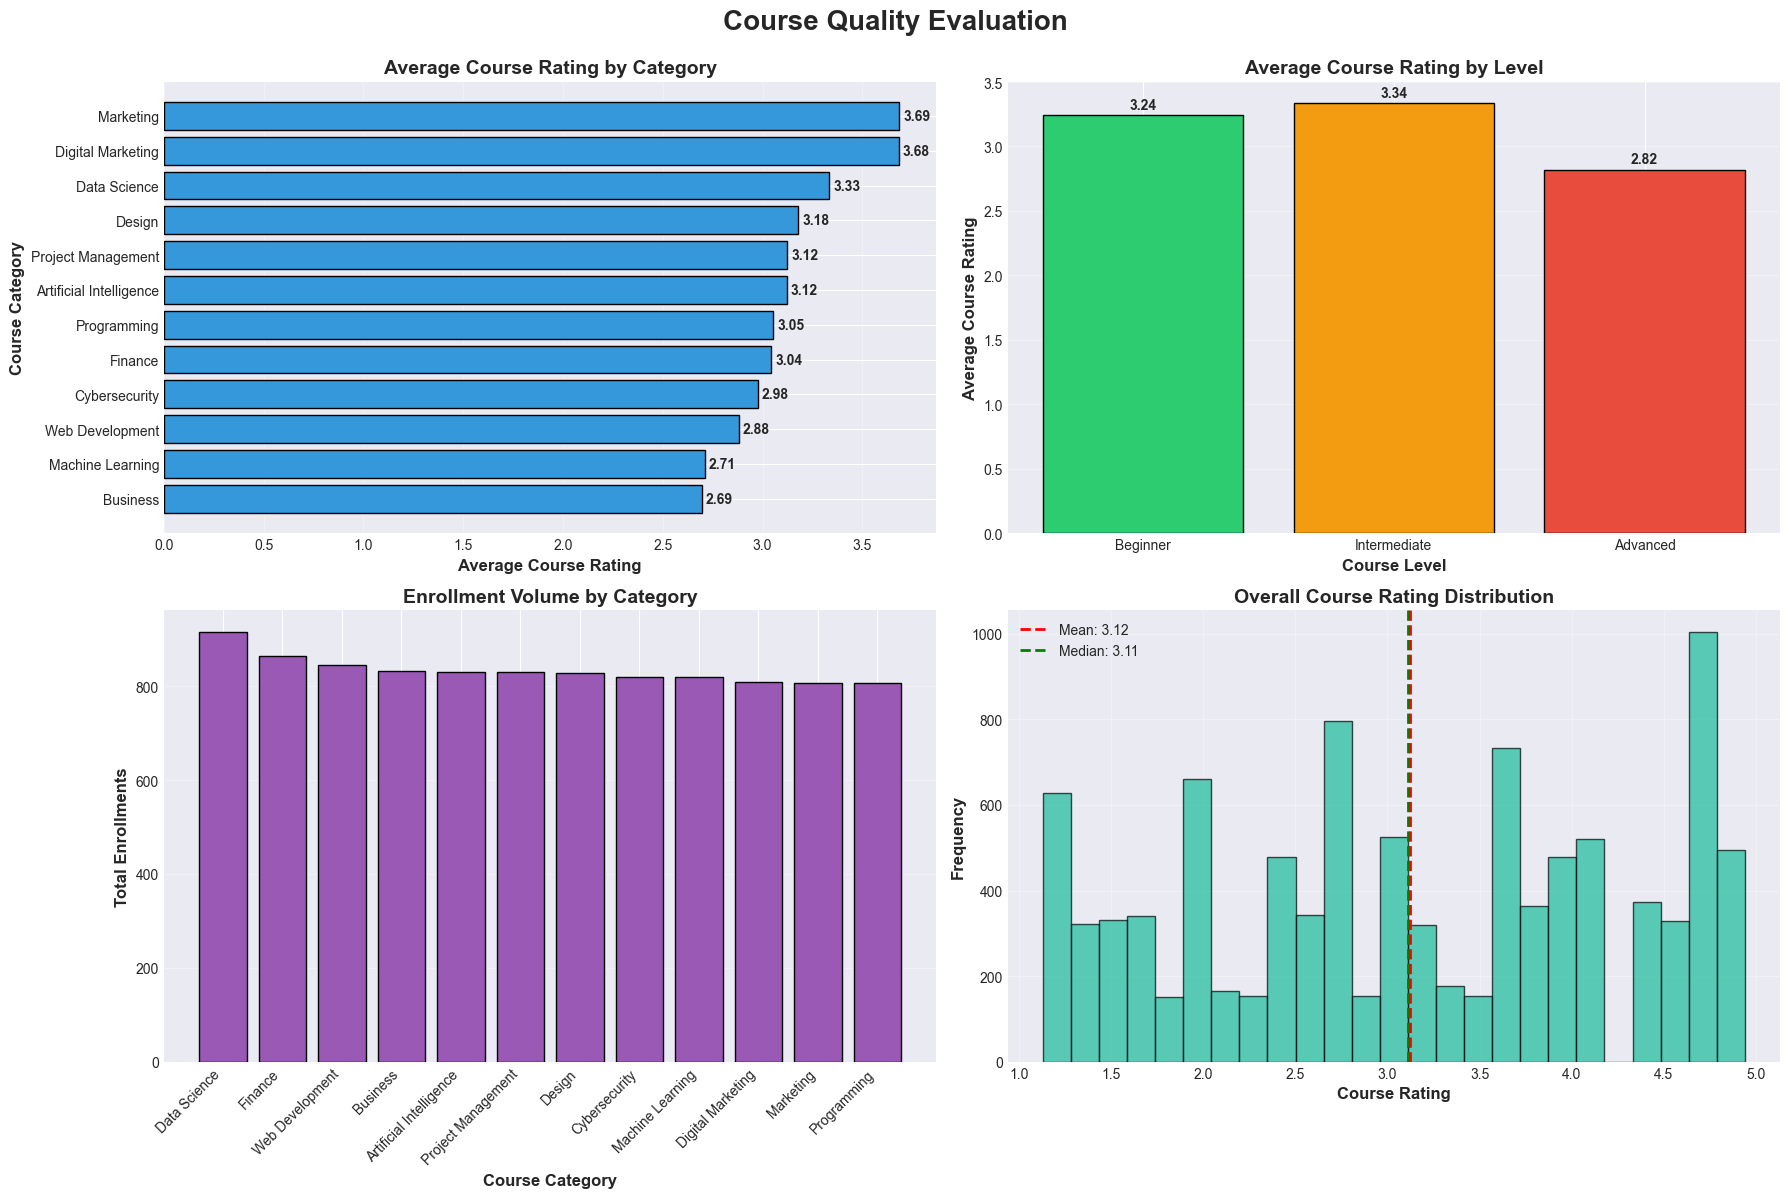


📊 Visualization saved: course_quality_evaluation.png


In [19]:
# Visualization 3: Course Quality Analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Course Quality Evaluation', fontsize=20, fontweight='bold', y=0.995)

# Subplot 1: Average Rating by Category
category_avg = category_stats['Avg_Rating'].sort_values(ascending=True)
axes[0, 0].barh(category_avg.index, category_avg.values, color='#3498db', edgecolor='black')
axes[0, 0].set_xlabel('Average Course Rating', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Course Category', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Average Course Rating by Category', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(category_avg.values):
    axes[0, 0].text(v + 0.02, i, f'{v:.2f}', va='center', fontweight='bold')

# Subplot 2: Average Rating by Level
level_order = ['Beginner', 'Intermediate', 'Advanced'] if all(x in level_stats.index for x in ['Beginner', 'Intermediate', 'Advanced']) else level_stats.index
level_ratings = [level_stats.loc[level, 'Avg_Rating'] if level in level_stats.index else 0 for level in level_order]
colors_level = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0, 1].bar(level_order, level_ratings, color=colors_level, edgecolor='black')
axes[0, 1].set_xlabel('Course Level', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Average Course Rating', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Average Course Rating by Level', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(level_ratings):
    axes[0, 1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Subplot 3: Enrollment Distribution by Category
category_enrollments = category_stats['Total_Enrollments'].sort_values(ascending=False)
axes[1, 0].bar(range(len(category_enrollments)), category_enrollments.values, 
               color='#9b59b6', edgecolor='black')
axes[1, 0].set_xticks(range(len(category_enrollments)))
axes[1, 0].set_xticklabels(category_enrollments.index, rotation=45, ha='right')
axes[1, 0].set_xlabel('Course Category', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Total Enrollments', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Enrollment Volume by Category', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Subplot 4: Course Rating Distribution (Overall)
axes[1, 1].hist(merged_df['CourseRating'], bins=25, color='#1abc9c', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(merged_df['CourseRating'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f"Mean: {merged_df['CourseRating'].mean():.2f}")
axes[1, 1].axvline(merged_df['CourseRating'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f"Median: {merged_df['CourseRating'].median():.2f}")
axes[1, 1].set_xlabel('Course Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Overall Course Rating Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('course_quality_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved: course_quality_evaluation.png")

## 7. Instructor Impact on Course Success

In [20]:
# Categorize instructors into rating tiers
instructor_profile['RatingTier'] = pd.cut(
    instructor_profile['TeacherRating'], 
    bins=[0, 3.5, 4.0, 5.0], 
    labels=['Low-Rated (≤3.5)', 'Mid-Rated (3.5-4.0)', 'High-Rated (>4.0)']
)

# Add rating tier to merged dataset
merged_df = merged_df.merge(
    instructor_profile[['TeacherID', 'RatingTier']], 
    on='TeacherID', 
    how='left'
)

print("="*80)
print("INSTRUCTOR IMPACT ANALYSIS")
print("="*80)

# Compare course ratings by instructor tier
tier_analysis = merged_df.groupby('RatingTier').agg({
    'CourseRating': ['mean', 'median', 'std'],
    'TransactionID': 'count',
    'TeacherID': 'nunique'
}).round(3)
tier_analysis.columns = ['Avg_Course_Rating', 'Median_Course_Rating', 'Std_Course_Rating', 'Total_Enrollments', 'Num_Instructors']
display(tier_analysis)

print("\n" + "="*80)
print("ENROLLMENT DISTRIBUTION BY INSTRUCTOR TIER")
print("="*80)
print(tier_analysis[['Total_Enrollments', 'Num_Instructors']])

INSTRUCTOR IMPACT ANALYSIS


,Avg_Course_Rating,Median_Course_Rating,Std_Course_Rating,Total_Enrollments,Num_Instructors
RatingTier,,,,,
Low-Rated (≤3.5),3.146,3.15,1.153,2504,39
Mid-Rated (3.5-4.0),2.989,3.02,1.095,676,10
High-Rated (>4.0),3.128,3.11,1.163,6820,11



ENROLLMENT DISTRIBUTION BY INSTRUCTOR TIER
                     Total_Enrollments  Num_Instructors
RatingTier                                             
Low-Rated (≤3.5)                  2504               39
Mid-Rated (3.5-4.0)                676               10
High-Rated (>4.0)                 6820               11


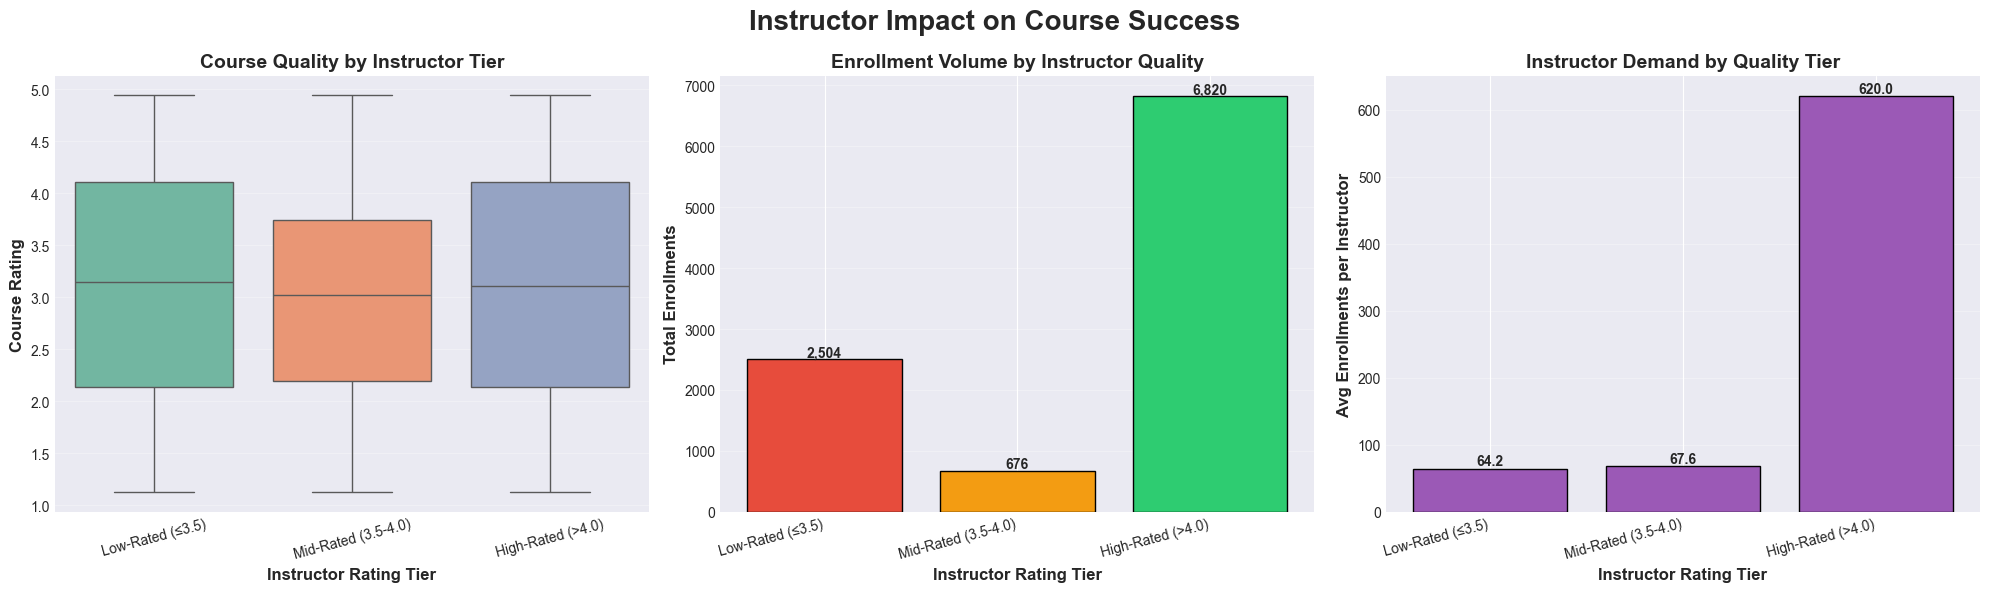


📊 Visualization saved: instructor_impact_analysis.png


In [21]:
# Visualization 4: Instructor Impact Analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Instructor Impact on Course Success', fontsize=20, fontweight='bold')

# Subplot 1: Course Rating by Instructor Tier (Box Plot)
tier_order = ['Low-Rated (≤3.5)', 'Mid-Rated (3.5-4.0)', 'High-Rated (>4.0)']
merged_df_filtered = merged_df[merged_df['RatingTier'].notna()]
sns.boxplot(data=merged_df_filtered, x='RatingTier', y='CourseRating', 
            order=tier_order, palette='Set2', ax=axes[0])
axes[0].set_xlabel('Instructor Rating Tier', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Course Rating', fontsize=12, fontweight='bold')
axes[0].set_title('Course Quality by Instructor Tier', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2: Enrollment Volume by Tier
tier_enrollments = tier_analysis['Total_Enrollments']
colors_tier = ['#e74c3c', '#f39c12', '#2ecc71']
axes[1].bar(range(len(tier_enrollments)), tier_enrollments.values, 
            color=colors_tier, edgecolor='black')
axes[1].set_xticks(range(len(tier_enrollments)))
axes[1].set_xticklabels(tier_enrollments.index, rotation=15, ha='right')
axes[1].set_xlabel('Instructor Rating Tier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Enrollments', fontsize=12, fontweight='bold')
axes[1].set_title('Enrollment Volume by Instructor Quality', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(tier_enrollments.values):
    axes[1].text(i, v + 50, f'{int(v):,}', ha='center', fontweight='bold')

# Subplot 3: Average Enrollments per Instructor
avg_enrollments_per_instructor = tier_analysis['Total_Enrollments'] / tier_analysis['Num_Instructors']
axes[2].bar(range(len(avg_enrollments_per_instructor)), avg_enrollments_per_instructor.values, 
            color='#9b59b6', edgecolor='black')
axes[2].set_xticks(range(len(avg_enrollments_per_instructor)))
axes[2].set_xticklabels(avg_enrollments_per_instructor.index, rotation=15, ha='right')
axes[2].set_xlabel('Instructor Rating Tier', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Avg Enrollments per Instructor', fontsize=12, fontweight='bold')
axes[2].set_title('Instructor Demand by Quality Tier', fontsize=14, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(avg_enrollments_per_instructor.values):
    axes[2].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('instructor_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved: instructor_impact_analysis.png")

## 8. Expertise-Based Performance Insights

In [22]:
# Expertise analysis
print("="*80)
print("PERFORMANCE BY INSTRUCTOR EXPERTISE")
print("="*80)

expertise_stats = instructor_profile.groupby('Expertise').agg({
    'TeacherRating': ['mean', 'median', 'std', 'count'],
    'TotalEnrollments': 'sum',
    'AvgCourseRating': 'mean'
}).round(3)
expertise_stats.columns = ['Avg_Teacher_Rating', 'Median_Teacher_Rating', 'Std_Teacher_Rating', 
                           'Num_Instructors', 'Total_Enrollments', 'Avg_Course_Rating']
expertise_stats = expertise_stats.sort_values('Avg_Teacher_Rating', ascending=False)
display(expertise_stats)

print("\n" + "="*80)
print("TOP 5 EXPERTISE AREAS BY INSTRUCTOR QUALITY")
print("="*80)
display(expertise_stats.nlargest(5, 'Avg_Teacher_Rating')[['Avg_Teacher_Rating', 'Num_Instructors', 'Total_Enrollments']])

PERFORMANCE BY INSTRUCTOR EXPERTISE


,Avg_Teacher_Rating,Median_Teacher_Rating,Std_Teacher_Rating,Num_Instructors,Total_Enrollments,Avg_Course_Rating
Expertise,,,,,,
Marketing,4.290,4.290,NaN,1,120,3.647
Machine Learning,4.234,4.360,0.557,5,3303,2.775
Programming,3.950,3.950,NaN,1,123,2.980
Cybersecurity,3.469,3.530,0.746,9,3450,3.038
Finance,3.265,3.145,0.601,6,410,3.166
Artificial Intelligence,3.173,3.325,0.914,6,389,3.155
Digital Marketing,3.050,3.230,0.837,11,479,3.547
Data Science,3.030,3.070,0.540,5,432,3.283
Project Management,2.664,2.450,1.213,5,368,3.083



TOP 5 EXPERTISE AREAS BY INSTRUCTOR QUALITY


,Avg_Teacher_Rating,Num_Instructors,Total_Enrollments
Expertise,,,
Marketing,4.290,1,120
Machine Learning,4.234,5,3303
Programming,3.950,1,123
Cybersecurity,3.469,9,3450
Finance,3.265,6,410


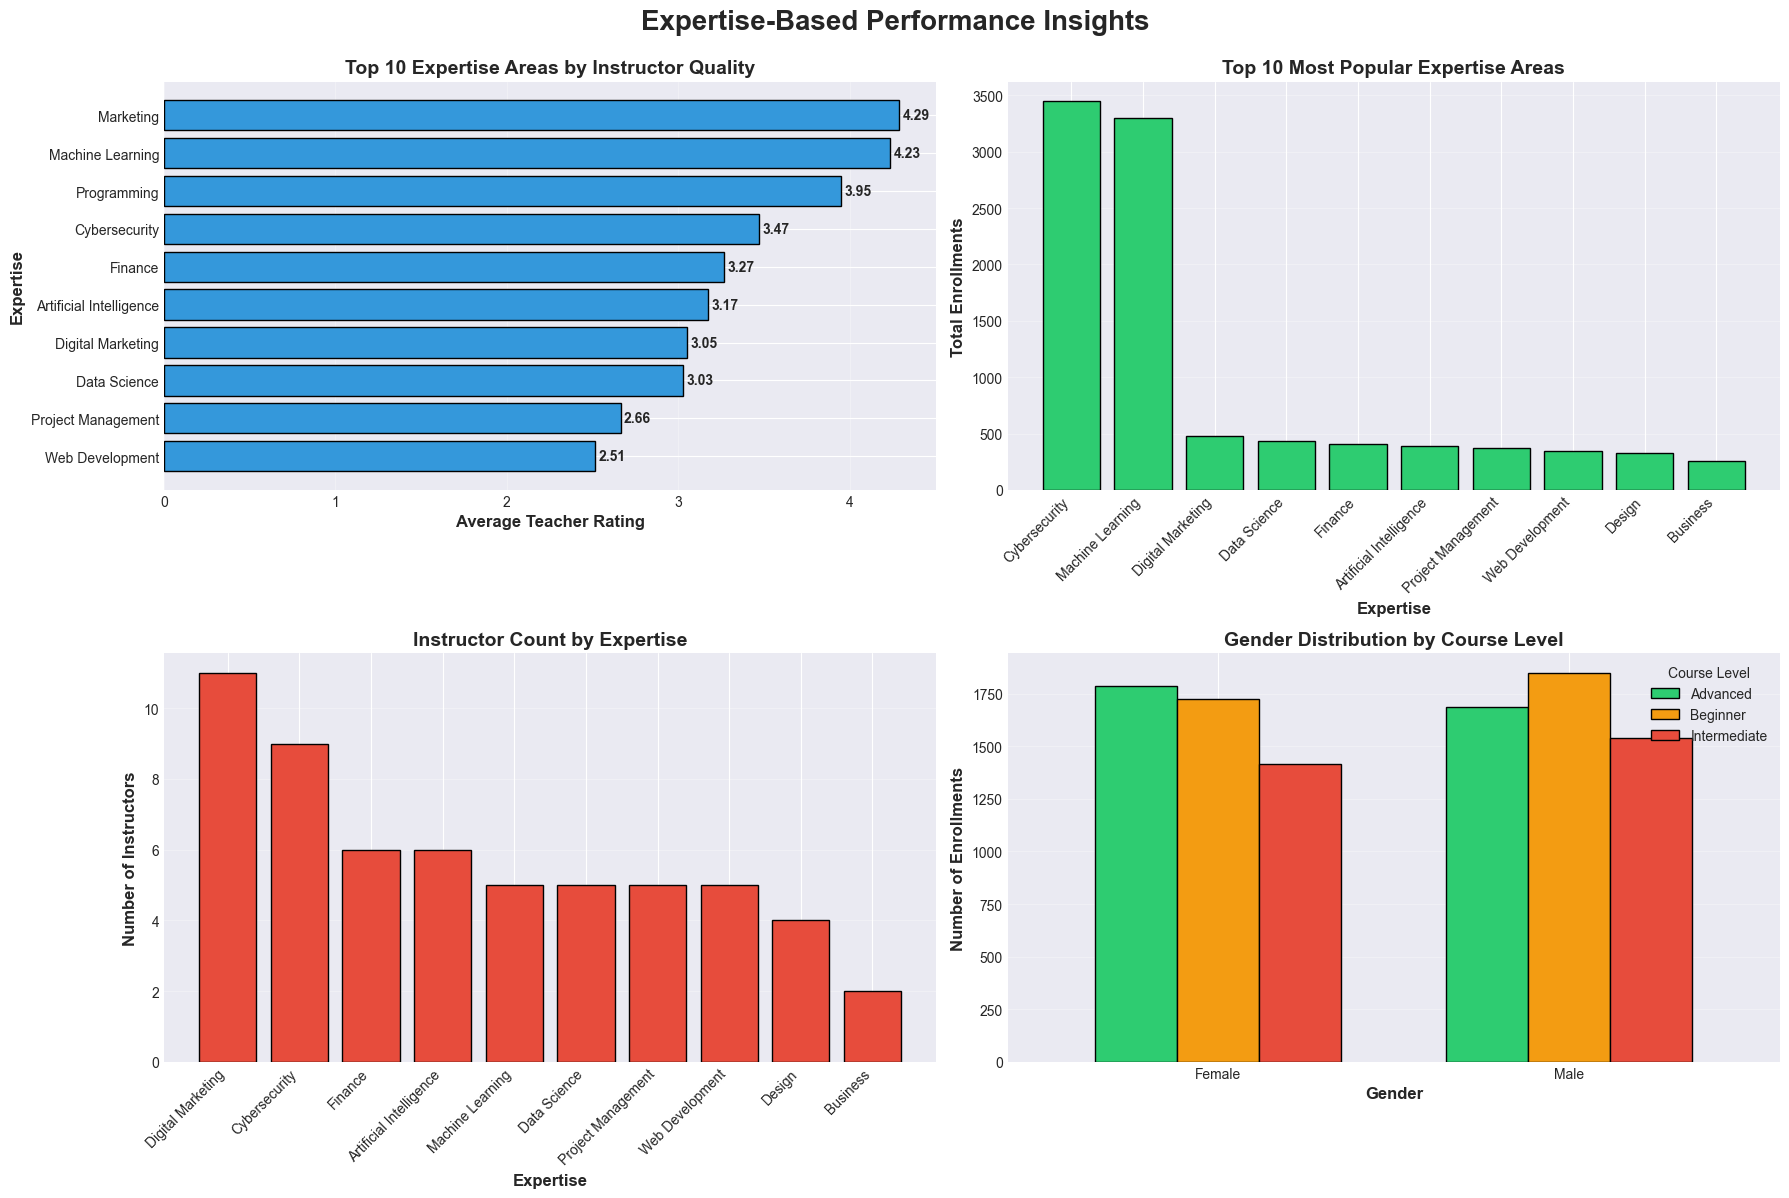


📊 Visualization saved: expertise_performance_insights.png


In [23]:
# Visualization 5: Expertise-Based Analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Expertise-Based Performance Insights', fontsize=20, fontweight='bold', y=0.995)

# Subplot 1: Average Teacher Rating by Expertise
expertise_top10 = expertise_stats.nlargest(10, 'Avg_Teacher_Rating')['Avg_Teacher_Rating'].sort_values(ascending=True)
axes[0, 0].barh(expertise_top10.index, expertise_top10.values, color='#3498db', edgecolor='black')
axes[0, 0].set_xlabel('Average Teacher Rating', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Expertise', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Top 10 Expertise Areas by Instructor Quality', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(expertise_top10.values):
    axes[0, 0].text(v + 0.02, i, f'{v:.2f}', va='center', fontweight='bold')

# Subplot 2: Total Enrollments by Expertise
expertise_enrollment = expertise_stats.nlargest(10, 'Total_Enrollments')['Total_Enrollments'].sort_values(ascending=False)
axes[0, 1].bar(range(len(expertise_enrollment)), expertise_enrollment.values, 
               color='#2ecc71', edgecolor='black')
axes[0, 1].set_xticks(range(len(expertise_enrollment)))
axes[0, 1].set_xticklabels(expertise_enrollment.index, rotation=45, ha='right')
axes[0, 1].set_xlabel('Expertise', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Enrollments', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Top 10 Most Popular Expertise Areas', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Subplot 3: Number of Instructors by Expertise
expertise_count = expertise_stats.nlargest(10, 'Num_Instructors')['Num_Instructors'].sort_values(ascending=False)
axes[1, 0].bar(range(len(expertise_count)), expertise_count.values, 
               color='#e74c3c', edgecolor='black')
axes[1, 0].set_xticks(range(len(expertise_count)))
axes[1, 0].set_xticklabels(expertise_count.index, rotation=45, ha='right')
axes[1, 0].set_xlabel('Expertise', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Instructors', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Instructor Count by Expertise', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Subplot 4: Gender distribution by Course Level
gender_level = merged_df.groupby(['Gender', 'CourseLevel']).size().unstack(fill_value=0)
gender_level.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#f39c12', '#e74c3c'], 
                  edgecolor='black', width=0.7)
axes[1, 1].set_xlabel('Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Number of Enrollments', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Gender Distribution by Course Level', fontsize=14, fontweight='bold')
axes[1, 1].legend(title='Course Level', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('expertise_performance_insights.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved: expertise_performance_insights.png")

## 9. Key Performance Indicators (KPIs)

In [24]:
# Calculate comprehensive KPIs
print("="*80)
print("KEY PERFORMANCE INDICATORS (KPIs)")
print("="*80)

# Average Teacher Rating
avg_teacher_rating = instructor_profile['TeacherRating'].mean()
print(f"\n1. Average Teacher Rating: {avg_teacher_rating:.3f}")
print(f"   → Teaching quality benchmark across the platform")

# Average Course Rating
avg_course_rating = merged_df['CourseRating'].mean()
print(f"\n2. Average Course Rating: {avg_course_rating:.3f}")
print(f"   → Content effectiveness measure")

# Rating Consistency Index (Lower std = higher consistency)
teacher_rating_std = instructor_profile['TeacherRating'].std()
rating_consistency_index = 1 / (1 + teacher_rating_std)  # Normalized consistency
print(f"\n3. Rating Consistency Index: {rating_consistency_index:.3f}")
print(f"   → Instructor reliability measure (closer to 1 = more consistent)")
print(f"   → Standard Deviation of Teacher Ratings: {teacher_rating_std:.3f}")

# Experience Impact Score
experience_impact_score = corr_exp_teacher
print(f"\n4. Experience Impact Score: {experience_impact_score:.3f}")
print(f"   → Correlation between experience and teacher rating")
print(f"   → Interpretation: {'Positive' if experience_impact_score > 0 else 'Negative'} correlation")

# Enrollment Influence Ratio
high_rated_enrollments = merged_df[merged_df['RatingTier'] == 'High-Rated (>4.0)']['TransactionID'].count()
total_enrollments = merged_df['TransactionID'].count()
enrollment_influence_ratio = high_rated_enrollments / total_enrollments
print(f"\n5. Enrollment Influence Ratio: {enrollment_influence_ratio:.3f}")
print(f"   → Proportion of enrollments with high-rated instructors")
print(f"   → High-rated instructor enrollments: {high_rated_enrollments:,} / {total_enrollments:,}")

# Additional KPIs
print(f"\n6. Total Unique Instructors: {instructor_profile['TeacherID'].nunique()}")
print(f"\n7. Total Unique Courses: {merged_df['CourseID'].nunique()}")
print(f"\n8. Total Enrollments: {total_enrollments:,}")
print(f"\n9. Average Experience Level: {instructor_profile['YearsOfExperience'].mean():.1f} years")
print(f"\n10. Teacher-Course Rating Correlation: {corr_teacher_course:.3f}")
print(f"    → Alignment between instructor quality and course quality")

KEY PERFORMANCE INDICATORS (KPIs)

1. Average Teacher Rating: 3.125
   → Teaching quality benchmark across the platform

2. Average Course Rating: 3.123
   → Content effectiveness measure

3. Rating Consistency Index: 0.513
   → Instructor reliability measure (closer to 1 = more consistent)
   → Standard Deviation of Teacher Ratings: 0.950

4. Experience Impact Score: 0.598
   → Correlation between experience and teacher rating
   → Interpretation: Positive correlation

5. Enrollment Influence Ratio: 0.682
   → Proportion of enrollments with high-rated instructors
   → High-rated instructor enrollments: 6,820 / 10,000

6. Total Unique Instructors: 60

7. Total Unique Courses: 60

8. Total Enrollments: 10,000

9. Average Experience Level: 6.3 years

10. Teacher-Course Rating Correlation: 0.000
    → Alignment between instructor quality and course quality


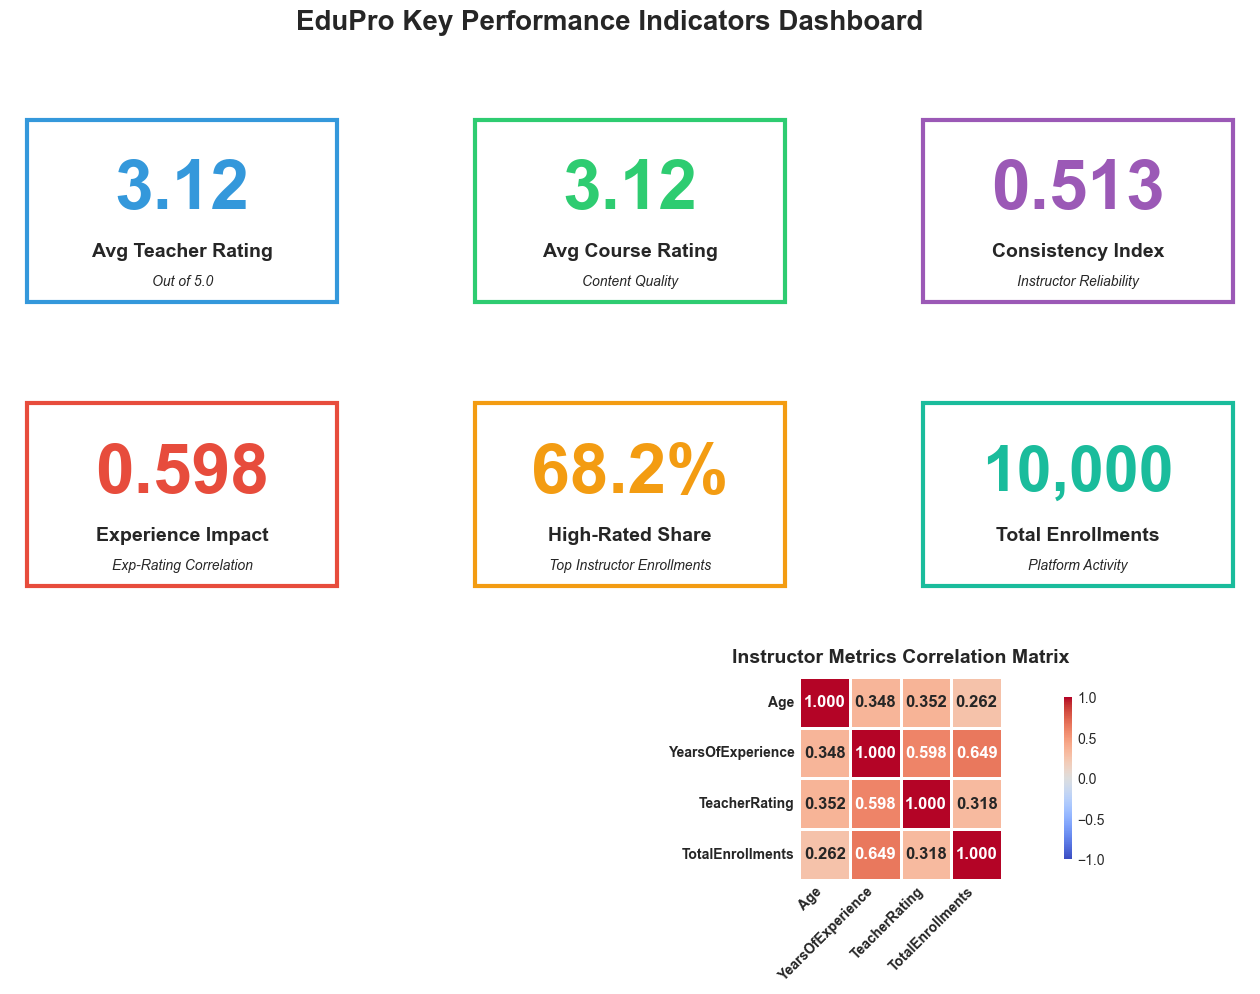


📊 Visualization saved: kpi_dashboard.png


In [25]:
# Visualization 6: KPI Dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)
fig.suptitle('EduPro Key Performance Indicators Dashboard', fontsize=20, fontweight='bold', y=0.98)

# KPI 1: Average Teacher Rating (Gauge)
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.6, f"{avg_teacher_rating:.2f}", ha='center', va='center', fontsize=50, fontweight='bold', color='#3498db')
ax1.text(0.5, 0.3, "Avg Teacher Rating", ha='center', va='center', fontsize=14, fontweight='bold')
ax1.text(0.5, 0.15, "Out of 5.0", ha='center', va='center', fontsize=10, style='italic')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#3498db', linewidth=3))

# KPI 2: Average Course Rating
ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.6, f"{avg_course_rating:.2f}", ha='center', va='center', fontsize=50, fontweight='bold', color='#2ecc71')
ax2.text(0.5, 0.3, "Avg Course Rating", ha='center', va='center', fontsize=14, fontweight='bold')
ax2.text(0.5, 0.15, "Content Quality", ha='center', va='center', fontsize=10, style='italic')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#2ecc71', linewidth=3))

# KPI 3: Rating Consistency Index
ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.6, f"{rating_consistency_index:.3f}", ha='center', va='center', fontsize=50, fontweight='bold', color='#9b59b6')
ax3.text(0.5, 0.3, "Consistency Index", ha='center', va='center', fontsize=14, fontweight='bold')
ax3.text(0.5, 0.15, "Instructor Reliability", ha='center', va='center', fontsize=10, style='italic')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')
ax3.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#9b59b6', linewidth=3))

# KPI 4: Experience Impact Score
ax4 = fig.add_subplot(gs[1, 0])
ax4.text(0.5, 0.6, f"{experience_impact_score:.3f}", ha='center', va='center', fontsize=50, fontweight='bold', color='#e74c3c')
ax4.text(0.5, 0.3, "Experience Impact", ha='center', va='center', fontsize=14, fontweight='bold')
ax4.text(0.5, 0.15, "Exp-Rating Correlation", ha='center', va='center', fontsize=10, style='italic')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')
ax4.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#e74c3c', linewidth=3))

# KPI 5: Enrollment Influence Ratio
ax5 = fig.add_subplot(gs[1, 1])
ax5.text(0.5, 0.6, f"{enrollment_influence_ratio:.1%}", ha='center', va='center', fontsize=50, fontweight='bold', color='#f39c12')
ax5.text(0.5, 0.3, "High-Rated Share", ha='center', va='center', fontsize=14, fontweight='bold')
ax5.text(0.5, 0.15, "Top Instructor Enrollments", ha='center', va='center', fontsize=10, style='italic')
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1)
ax5.axis('off')
ax5.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#f39c12', linewidth=3))

# KPI 6: Total Enrollments
ax6 = fig.add_subplot(gs[1, 2])
ax6.text(0.5, 0.6, f"{total_enrollments:,}", ha='center', va='center', fontsize=45, fontweight='bold', color='#1abc9c')
ax6.text(0.5, 0.3, "Total Enrollments", ha='center', va='center', fontsize=14, fontweight='bold')
ax6.text(0.5, 0.15, "Platform Activity", ha='center', va='center', fontsize=10, style='italic')
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')
ax6.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#1abc9c', linewidth=3))

# Bottom row: Correlation Heatmap
ax7 = fig.add_subplot(gs[2, :])
correlation_data = instructor_profile[['Age', 'YearsOfExperience', 'TeacherRating', 'TotalEnrollments']].corr()
sns.heatmap(correlation_data, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=2, cbar_kws={'shrink': 0.8}, ax=ax7, 
            vmin=-1, vmax=1, annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax7.set_title('Instructor Metrics Correlation Matrix', fontsize=14, fontweight='bold', pad=10)
ax7.set_xticklabels(ax7.get_xticklabels(), rotation=45, ha='right', fontweight='bold')
ax7.set_yticklabels(ax7.get_yticklabels(), rotation=0, fontweight='bold')

plt.savefig('kpi_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Visualization saved: kpi_dashboard.png")

## 10. Summary and Key Insights

In [26]:
print("="*80)
print("EXECUTIVE SUMMARY - KEY INSIGHTS")
print("="*80)

print("\n1. INSTRUCTOR PERFORMANCE DISTRIBUTION")
print(f"   • Average instructor rating: {avg_teacher_rating:.2f}/5.0")
print(f"   • Rating standard deviation: {teacher_rating_std:.2f} (consistency measure)")
print(f"   • Top 10% of instructors rated above: {instructor_profile['TeacherRating'].quantile(0.9):.2f}")

print("\n2. EXPERIENCE VS PERFORMANCE")
print(f"   • Experience-Rating correlation: {corr_exp_teacher:.3f} ({('Positive' if corr_exp_teacher > 0 else 'Negative')} relationship)")
print(f"   • Average teaching experience: {instructor_profile['YearsOfExperience'].mean():.1f} years")
print(f"   • Experience explains {(corr_exp_teacher**2)*100:.1f}% of rating variance")

print("\n3. INSTRUCTOR-COURSE QUALITY ALIGNMENT")
print(f"   • Teacher-Course rating correlation: {corr_teacher_course:.3f}")
print(f"   • Average course rating: {avg_course_rating:.2f}/5.0")
print(f"   • High-rated instructors drive {enrollment_influence_ratio:.1%} of total enrollments")

print("\n4. TOP PERFORMING CATEGORIES")
top_3_categories = category_stats.nlargest(3, 'Avg_Rating')
for idx, (category, row) in enumerate(top_3_categories.iterrows(), 1):
    print(f"   • #{idx}: {category} - Rating: {row['Avg_Rating']:.2f}, Enrollments: {int(row['Total_Enrollments']):,}")

print("\n5. EXPERTISE INSIGHTS")
top_3_expertise = expertise_stats.nlargest(3, 'Avg_Teacher_Rating')
for idx, (expertise, row) in enumerate(top_3_expertise.iterrows(), 1):
    print(f"   • #{idx}: {expertise} - Rating: {row['Avg_Teacher_Rating']:.2f}, Instructors: {int(row['Num_Instructors'])}")

print("\n6. ENROLLMENT PATTERNS")
print(f"   • Total platform enrollments: {total_enrollments:,}")
print(f"   • Enrollments per instructor (avg): {total_enrollments / instructor_profile.shape[0]:.1f}")
print(f"   • High-rated instructors: {tier_analysis.loc['High-Rated (>4.0)', 'Total_Enrollments']:,.0f} enrollments")
print(f"   • Low-rated instructors: {tier_analysis.loc['Low-Rated (≤3.5)', 'Total_Enrollments']:,.0f} enrollments")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)
print("\n✓ Focus professional development on instructors with <3.5 ratings")
print("✓ Leverage high-rated instructors for mentorship programs")
print("✓ Investigate why certain expertise areas consistently outperform others")
print("✓ Develop quality standards based on top-performing instructor characteristics")
print("✓ Monitor course-instructor alignment to ensure quality consistency")
print("\n" + "="*80)

EXECUTIVE SUMMARY - KEY INSIGHTS

1. INSTRUCTOR PERFORMANCE DISTRIBUTION
   • Average instructor rating: 3.12/5.0
   • Rating standard deviation: 0.95 (consistency measure)
   • Top 10% of instructors rated above: 4.28

2. EXPERIENCE VS PERFORMANCE
   • Experience-Rating correlation: 0.598 (Positive relationship)
   • Average teaching experience: 6.3 years
   • Experience explains 35.8% of rating variance

3. INSTRUCTOR-COURSE QUALITY ALIGNMENT
   • Teacher-Course rating correlation: 0.000
   • Average course rating: 3.12/5.0
   • High-rated instructors drive 68.2% of total enrollments

4. TOP PERFORMING CATEGORIES
   • #1: Marketing - Rating: 3.69, Enrollments: 806
   • #2: Digital Marketing - Rating: 3.68, Enrollments: 808
   • #3: Data Science - Rating: 3.33, Enrollments: 916

5. EXPERTISE INSIGHTS
   • #1: Marketing - Rating: 4.29, Instructors: 1
   • #2: Machine Learning - Rating: 4.23, Instructors: 5
   • #3: Programming - Rating: 3.95, Instructors: 1

6. ENROLLMENT PATTERNS
   •

In [27]:
# Export processed data for Streamlit dashboard
instructor_profile.to_csv('instructor_profile_analysis.csv', index=False)
merged_df.to_csv('merged_edupro_data.csv', index=False)
category_stats.to_csv('category_performance.csv')
expertise_stats.to_csv('expertise_performance.csv')

print("\n✅ Analysis Complete!")
print("\n📁 Exported Files:")
print("   • instructor_profile_analysis.csv")
print("   • merged_edupro_data.csv")
print("   • category_performance.csv")
print("   • expertise_performance.csv")
print("\n📊 Visualizations Created:")
print("   • instructor_profile_analysis.png")
print("   • experience_performance_analysis.png")
print("   • course_quality_evaluation.png")
print("   • instructor_impact_analysis.png")
print("   • expertise_performance_insights.png")
print("   • kpi_dashboard.png")


✅ Analysis Complete!

📁 Exported Files:
   • instructor_profile_analysis.csv
   • merged_edupro_data.csv
   • category_performance.csv
   • expertise_performance.csv

📊 Visualizations Created:
   • instructor_profile_analysis.png
   • experience_performance_analysis.png
   • course_quality_evaluation.png
   • instructor_impact_analysis.png
   • expertise_performance_insights.png
   • kpi_dashboard.png
